# Algorithmic Fairness, Accountability, and Ethics, Spring 2026
# Exercise 3

## Task 0 (Setup)

We use the same dataset as in week 2. If you missed to install the module, please carry out the installation tasks at <https://github.com/zykls/folktables#basic-installation-instructions>.

After successful installation, you should be able to run the following code to generate a prediction task.
To make your life easier, we made the `BasicProblem`-magic from the `folktables` package (see exercises of week 2) explicit in this task.
This way, you can get access to different encodings of the data. 

**Note**: Some Windows users could not run the line `acs_data = data_source.get_data(states=["CA"], download=True)`. The dataset is available as a zip file on learnIT under week 2. Unzip it in the notebook's location, and set `download` to `False` in the code below.

In [47]:
from folktables.acs import adult_filter
from folktables import ACSDataSource
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# prediction task = 
## what we want to predict (target), 
## what information we have (features), 
## what groups we want to analyze (group), 
## and how we evaluate (train/test split)

data_source = ACSDataSource(survey_year='2018', horizon='1-Year', survey='person')
acs_data = data_source.get_data(states=["CA"], download=True)

feature_names = ['AGEP', # Age
                 "CIT", # Citizenship status
                 'COW', # Class of worker
                 "ENG", # Ability to speak English
                 'SCHL', # Educational attainment
                 'MAR', # Marital status
                 "HINS1", # Insurance through a current or former employer or union
                 "HINS2", # Insurance purchased directly from an insurance company
                 "HINS4", # Medicaid
                 "RAC1P", # Recoded detailed race code
                 'SEX']

target_name = "PINCP" # Total person's income

def data_processing(data, features, target_name:str, threshold: float = 25000):
    df = data
    ### Adult Filter (STARTS) (from Foltktables)
    df = df[~df["SEX"].isnull()]
    df = df[~df["RAC1P"].isnull()]
    df = df[df['AGEP'] > 16]
    df = df[df['PINCP'] > 100]
    df = df[df['WKHP'] > 0]
    df = df[df['PWGTP'] >= 1]
    ### Adult Filter (ENDS)
    ### Groups of interest
    sex = df["SEX"].values
    ### Target
    df["target"] = df[target_name] > threshold # to binary classification, true if income > threshold, false otherwise 
    target = df["target"].values
    df = df[features + ["target", target_name]] ##we want to keep df before one_hot encoding to make Bias Analysis
    df_processed = df[features].copy()
    
    # one-hot encoding for categorical features, we drop the first category to avoid multicollinearity, except for "ENG" where we keep the NaN category to capture missing data
    cols = [ "HINS1", "HINS2", "HINS4", "CIT", "COW", "SCHL", "MAR", "SEX", "RAC1P"]
    df_processed = pd.get_dummies(df_processed, prefix=None, prefix_sep='_', dummy_na=False, columns=cols, drop_first=True)
    df_processed = pd.get_dummies(df_processed, prefix=None, prefix_sep='_', dummy_na=True, columns=["ENG"], drop_first=True)
    return df_processed, df, target, sex

data, data_original, target, group = data_processing(acs_data, feature_names, target_name)

X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    data, target, group, test_size=0.2, random_state=0)

data.head()

,AGEP,HINS1_2,HINS2_2,HINS4_2,CIT_2,CIT_3,CIT_4,CIT_5,COW_2.0,COW_3.0,...,RAC1P_4,RAC1P_5,RAC1P_6,RAC1P_7,RAC1P_8,RAC1P_9,ENG_2.0,ENG_3.0,ENG_4.0,ENG_nan
0,30,True,True,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
6,21,True,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7,65,True,True,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
10,33,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13,18,True,False,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True


In [48]:
#Run this cell to use categorical features instead
catagorical=False
if catagorical:
    data, data_original, target, group = data_processing(acs_data, feature_names, target_name)
    data_original = data_original.dropna(axis=1)
    X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
        data_original[['AGEP', 'CIT', 'COW', 'SCHL', 'MAR', 'HINS1', 'HINS2', 'HINS4', 'RAC1P',
        'SEX']], target, group, test_size=0.2, random_state=0)

# Task 1 (Logistic regression)

1) Train a logistic regression classifier on the training dataset. In our setup, the following parameters worked out well: `LogisticRegression(max_iter=5000, penalty = "l2", C= 0.8497534359086438, tol=1e-4, solver = "saga")`. Which scaling considerations do you think are necessary?


**Which scaling considerations do you think are necessary?**

We have both binary features (0–1) from one-hot encoding and numeric features such as age with a larger range (18–99). Since we use logistic regression with L2 regularization and a gradient-based solver, scaling is important. Without scaling, features with larger magnitude could dominate the optimization process and be penalized differently by the regularization term. Therefore, numeric features such as age should be standardized to mean 0 and standard deviation 1 to ensure stable training and fair regularization. Binary features do not strictly require scaling, as they are already bounded between 0 and 1.


In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Scale numeric features and keep categorical features unchanged
numeric_features = ['AGEP']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ],
    remainder='passthrough'  
)

# Train a logistic regression model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=5000,
        penalty='l2', 
        C=0.8497534359086438, 
        tol=1e-4, 
        solver='saga'))
])     

model.fit(X_train, y_train)

/Users/hannah/Library/CloudStorage/OneDrive-ITU(2)/MSc semester 4/Algorithmic Fairness/Algorithmic_Fairness_2026/algo/lib/python3.11/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['AGEP'])])),
                ('classifier',
                 LogisticRegression(C=0.8497534359086438, max_iter=5000,
                                    solver='saga'))])

2) Report on the accuracy of the model. (If you are interested: How is the classification accuracy on the original dataset with categorial input?)

In [50]:
## accuracy 
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on test data: {accuracy:.4f}")

Accuracy on test data: 0.7747



3) Report on the model weights (sort them by weight). Which weights are most important? Explain the influence of the most important weights. (For example, "being female instead of male increases/decreases the odds for ... by ...".)

In [51]:
# sort the features by their weights
clf = model.named_steps['classifier']
coefficients = clf.coef_[0]
feature_names = model.named_steps['preprocessor'].get_feature_names_out() # ensure the feature names are correctly retrieved after preprocessing

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

coef_df_sorted = coef_df.sort_values(by='coefficient', ascending=False)

print("Top 10 positive coefficients:")
print(coef_df_sorted.head(10))

print("\nTop 10 negative coefficients:")
print(coef_df_sorted.tail(10))

Top 10 positive coefficients:
                 feature  coefficient
37  remainder__SCHL_24.0     2.034412
36  remainder__SCHL_23.0     1.982057
35  remainder__SCHL_22.0     1.823998
34  remainder__SCHL_21.0     1.407697
33  remainder__SCHL_20.0     0.787502
3     remainder__HINS4_2     0.742068
0              num__AGEP     0.610258
16   remainder__SCHL_3.0     0.516763
11    remainder__COW_5.0     0.515747
32  remainder__SCHL_19.0     0.477830

Top 10 negative coefficients:
                 feature  coefficient
38      remainder__MAR_2    -0.247237
27  remainder__SCHL_14.0    -0.250747
18   remainder__SCHL_5.0    -0.283984
52    remainder__ENG_3.0    -0.542082
41      remainder__MAR_5    -0.634221
12    remainder__COW_6.0    -0.687053
42      remainder__SEX_2    -0.785645
53    remainder__ENG_4.0    -0.875788
1     remainder__HINS1_2    -0.943205
14    remainder__COW_8.0    -1.450085


In [52]:
# find odds 

coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])

coef_df_sorted_abs = coef_df.sort_values(
    by='coefficient',
    key=abs,
    ascending=False
)

print("\nTop 10 by absolute coefficient (with odds ratios):")
print(coef_df_sorted_abs[['feature','coefficient','odds_ratio']].head(10))


Top 10 by absolute coefficient (with odds ratios):
                 feature  coefficient  odds_ratio
37  remainder__SCHL_24.0     2.034412    7.647756
36  remainder__SCHL_23.0     1.982057    7.257660
35  remainder__SCHL_22.0     1.823998    6.196583
14    remainder__COW_8.0    -1.450085    0.234550
34  remainder__SCHL_21.0     1.407697    4.086534
1     remainder__HINS1_2    -0.943205    0.389378
53    remainder__ENG_4.0    -0.875788    0.416534
33  remainder__SCHL_20.0     0.787502    2.197900
42      remainder__SEX_2    -0.785645    0.455825
3     remainder__HINS4_2     0.742068    2.100274


**Discussion of feature importance**

The most important feature (highest odds ratio) is education level. For example, having education level 24 (Doctorate degree) increases the odds of earning more than $25,000 by a factor of 7.65 compared to the reference lowest education category. The same pattern applies to other high education levels (SCHL_23, SCHL_22, etc.), which all substantially increase the odds of high income. This is expected, as higher education is strongly associated with higher earnings.

Class of worker also has a strong influence. For example, being in class-of-worker category 8 (COW_8), which corresponds to unpaid work, reduces the odds of earning more than $25,000 to about 23% of the reference group. This is intuitive, since unpaid workers are unlikely to earn high incomes.

Being in English category 4 reduces the odds of earning above $25,000 to about 42% of the reference group. This likely reflects the disadvantage in the labor market associated with limited English proficiency.

Interestingly, being in sex category 2 (female) reduces the odds of earning above $25,000 to about 46% of the odds for males (the reference group). This suggests a substantial gender gap in income in the dataset.


4) Find a negative or a positive instance, and discuss how you can use the weights discussion to create a counterfactual. (E.g., "By increasing/decreasing feature ... to ..., the person is classified as ...").

In [53]:
y_test_series = pd.Series(y_test, index=X_test.index)

# find positive instance
positive_instance = X_test.loc[y_test_series == 1].iloc[0]

print("\nPositive instance (income > 25k):")
print(positive_instance)

print("\nPredicted probability for this instance:")
predicted_prob = model.predict_proba(positive_instance.to_frame().T)[0, 1]
print(predicted_prob)

print("\nActual label for this instance:")
print(y_test_series[y_test_series == 1].iloc[0])

# find negative instance

negative_instance = X_test.loc[y_test_series == 0].iloc[0]

print("\nNegative instance (income <= 25k):")
print(negative_instance)

print("\nPredicted probability for this instance:")
predicted_prob_neg = model.predict_proba(negative_instance.to_frame().T)[0, 1]
print(predicted_prob_neg)

print("\nActual label for this instance:")
print(y_test_series[y_test_series == 0].iloc[0])


Positive instance (income > 25k):
AGEP            62
HINS1_2      False
HINS2_2       True
HINS4_2       True
CIT_2        False
CIT_3        False
CIT_4        False
CIT_5        False
COW_2.0      False
COW_3.0      False
COW_4.0      False
COW_5.0      False
COW_6.0      False
COW_7.0      False
COW_8.0      False
SCHL_2.0     False
SCHL_3.0     False
SCHL_4.0     False
SCHL_5.0     False
SCHL_6.0     False
SCHL_7.0     False
SCHL_8.0     False
SCHL_9.0     False
SCHL_10.0    False
SCHL_11.0    False
SCHL_12.0    False
SCHL_13.0    False
SCHL_14.0    False
SCHL_15.0    False
SCHL_16.0    False
SCHL_17.0    False
SCHL_18.0     True
SCHL_19.0    False
SCHL_20.0    False
SCHL_21.0    False
SCHL_22.0    False
SCHL_23.0    False
SCHL_24.0    False
MAR_2        False
MAR_3        False
MAR_4        False
MAR_5        False
SEX_2        False
RAC1P_2      False
RAC1P_3      False
RAC1P_4      False
RAC1P_5      False
RAC1P_6      False
RAC1P_7      False
RAC1P_8      False
RAC1P_9      Fa

**Counterfactual**

Summary of the positive instance
- Age: 62
- Education: SCHL_18 = True
- Male (SEX_2 = False → reference category male)
- Predicted probability: 0.92
- Correctly classified as income > 25k

Why is it classified as high income?
Even though SCHL_18 is not one of the very highest education levels, it still contributes positively compared to the reference education group.
Increasing age also has a  positive coefficient, and likely contributes to the prediction, since income generally increases with age/experience.
Additionally, being in the SEX rference group (male) increases odds of being in target group substantially.

Counterfactual 
If this person had a lower education level (the reference category instead of SCHL_18), the positive contribution from education would disappear.
This would reduce the log-odds and therefore lower the predicted probability.
However, since the predicted probability is very high (0.92), this single change might not be enough to flip the classification. We might also have to flipp class of worker, age or gender.


Summary of the negative instance
- Age: 33
- Education: SCHL_21 = True
- Female (SEX_2 = True)
- Predicted probability: 0.71
- Actually income ≤ 25k
- False positive

The negative instance is predicted as high income with probability 0.71, although the true label is low income. The main driver of the prediction is education level SCHL_21, which increases the odds of high income by a factor of about 4.09. A counterfactual change would be lowering the education level to the reference category, which would reduce the log-odds by approximately 1.41 and likely change the classification to low income. This demonstrates that education strongly influences the model’s decision.

# Task 2 (Decision tree)

1. Train a decision tree classifier on the training dataset. (You can work on the original dataset or on the one-hot encoded one.) The following parameter choices worked well in our setup: `(DecisionTreeClassifier(min_samples_split = 0.01, min_samples_leaf= 0.01, max_features="auto", max_depth = 15, criterion = "gini", random_state = 0))` Report on its accuracy. Visualize the tree using `plot_tree` from `sklearn`. Which parameters can you change the adapt the size of the tree? Try to find parameters that make the tree easier to understand.

Accuracy of deep decision tree: 0.79


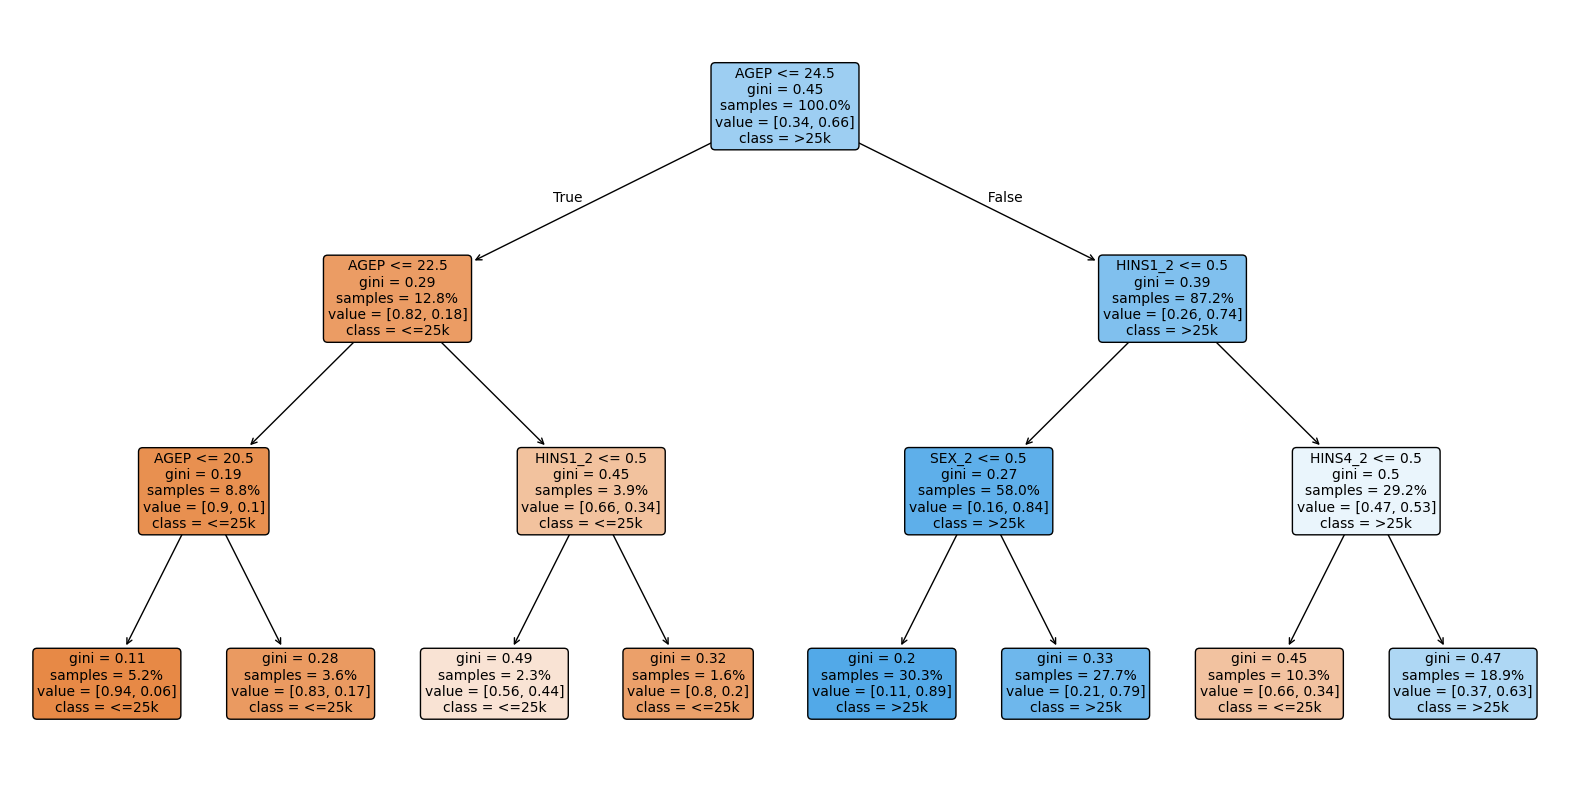

Accuracy of shallow decision tree: 0.78


In [61]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# train decision tree 
tree_model = DecisionTreeClassifier(
    min_samples_split = 0.01, 
    min_samples_leaf= 0.01, 
    max_features=None, 
    max_depth = 15, 
    criterion = "gini", 
    random_state = 0)

tree_model.fit(X_train, y_train)

#plot_tree(tree_model, feature_names=X_train.columns, class_names=['<=25k', '>25k'], filled=True)

# accuracy of deep decision tree
y_pred = tree_model.predict(X_test)
accuracy = (y_pred == y_test).mean()
print(f"Accuracy of deep decision tree: {accuracy:.2f}")

# train a shallow decision tree for better interpretability
shallow_tree_model = DecisionTreeClassifier(
    min_samples_split = 0.01, 
    min_samples_leaf= 0.01,
    max_features=None,
    max_depth = 3,
    criterion = "gini",
    random_state = 0)

shallow_tree_model.fit(X_train, y_train)

import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))  # larger figure

plot_tree(
    shallow_tree_model,
    feature_names=X_train.columns,
    class_names=['<=25k', '>25k'],
    filled=True,
    rounded=True,
    fontsize=10,        
    precision=2,        
    proportion=True     
)

plt.show()

# accuracy of shallow decision tree
y_pred_shallow = shallow_tree_model.predict(X_test)
accuracy_shallow = (y_pred_shallow == y_test).mean()
print(f"Accuracy of shallow decision tree: {accuracy_shallow:.2f}")


2. For two training examples, explain their classification given the decision tree.


In [62]:
# find two training examples 

y_train_pred = shallow_tree_model.predict(X_train)
low_idx = (y_train_pred == 0).nonzero()[0][0]
low_example = X_train.iloc[low_idx]
high_idx = (y_train_pred == 1).nonzero()[0][0]
high_example = X_train.iloc[high_idx]

print("Low income example:")
print(low_example)

print("\nHigh income example:")
print(high_example)

Low income example:
AGEP            23
HINS1_2      False
HINS2_2      False
HINS4_2       True
CIT_2        False
CIT_3        False
CIT_4        False
CIT_5        False
COW_2.0      False
COW_3.0      False
COW_4.0      False
COW_5.0      False
COW_6.0      False
COW_7.0      False
COW_8.0      False
SCHL_2.0     False
SCHL_3.0     False
SCHL_4.0     False
SCHL_5.0     False
SCHL_6.0     False
SCHL_7.0     False
SCHL_8.0     False
SCHL_9.0     False
SCHL_10.0    False
SCHL_11.0    False
SCHL_12.0    False
SCHL_13.0    False
SCHL_14.0    False
SCHL_15.0    False
SCHL_16.0    False
SCHL_17.0    False
SCHL_18.0    False
SCHL_19.0     True
SCHL_20.0    False
SCHL_21.0    False
SCHL_22.0    False
SCHL_23.0    False
SCHL_24.0    False
MAR_2        False
MAR_3        False
MAR_4        False
MAR_5         True
SEX_2         True
RAC1P_2      False
RAC1P_3      False
RAC1P_4      False
RAC1P_5      False
RAC1P_6      False
RAC1P_7      False
RAC1P_8      False
RAC1P_9      False
ENG_2.0    

**Predicted low income example path**
- AGE ≤ 24.5?
    - TRUE, Go left
- AGE < 22.5 
    - FALSE, Go right
- HINS_1 (insurance from employer)
    - FALSE, Go left
- Ends in leaf node predicting <=25k

**Predicted high income example path**
- AGE ≤ 24.5?
    - FALSE, Go right
- HINS_1 < 0.5 (insurance from employer)
    - True, Go left
- SEX (female)
    - FALSE, Go right
- Ends in leaf node predicting >25k

**Interpretation**
In contrast to logistic regression, where education level had the strongest influence on income prediction, the decision tree primarily splits on age, insurance status, and sex. Education does not appear in the shallow tree, meaning that for this interpretable version of the model, age is the dominant factor in classification. This highlights how different models can rely on different features even when trained on the same data.

**Accuracy**
Regarding accuracy, changing the three from deep to shallow, gratly imporves interpretability, and only reduced accuracy of the model from 0.79 to 0.78

3. Compute feature importance as shown in the lecture. Which features are most important?

In [66]:
# compute important features for the decision tree

feature_importances = shallow_tree_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importances
}).sort_values(by='importance', ascending=False)

print("Feature importances for the shallow decision tree:")
print(feature_importance_df.head(10))


Feature importances for the shallow decision tree:
      feature  importance
0        AGEP    0.578896
1     HINS1_2    0.310734
3     HINS4_2    0.087146
42      SEX_2    0.023223
30  SCHL_17.0    0.000000
31  SCHL_18.0    0.000000
32  SCHL_19.0    0.000000
33  SCHL_20.0    0.000000
34  SCHL_21.0    0.000000
35  SCHL_22.0    0.000000


**Feature importance**

The most important feature in the shallow decision tree is AGEP, with an importance of 0.579. This means that age accounts for nearly 58% of the total reduction in Gini impurity and is therefore the dominant factor in the model’s decisions. This is expected, since AGE is used at the root node and affects all observations.

The second most important feature is HINS1_2 (importance 0.311), which further splits the majority of older individuals. This shows that insurance status plays a substantial role in income prediction within this model.

Smaller contributions come from HINS4_2 (0.087) and SEX_2 (0.023), indicating that Medicaid status and sex have some influence, but much less compared to age and employer-based insurance.

All remaining features, including education levels (SCHL_*), marital status, race, and English proficiency, have zero importance in the shallow tree because they are not used in any splits.


4. Provide a counterfactual, as in Task 2.

If the predicted low income instance were 25 years old instead of 23, with all other characteristics unchanged, they would follow the right branch at the root split and be classified as earning more than 25k.

# Task 3 (Comparison)

Now you have both an interpretable logistic regression model and an interpretable decision tree model. Reflect on the explanations you can obtain from these two models: Do explanations from one model translate to the other? Do the counterfactuals from one work in the other model?  

**Reflections**

In the logistic regression model, the most important feature was education level, with high education strongly increasing the odds of earning more than 25k. The explanation is global and additive: each feature contributes linearly (in log-odds) to the final prediction. Every feature always has some influence.

In contrast, the decision tree model primarily relied on age, insurance status (HINS1_2), and sex. Education did not appear at all in the shallow tree and therefore had zero importance. The tree explanation is hierarchical and rule-based: only features used along the decision path influence the prediction.

This shows that explanations from one model do not necessarily translate to the other. A feature that is highly important in logistic regression (education) may be irrelevant in the decision tree.

**Do counterfactuals translate between models?**

Not reliably.

In the decision tree, changing age from 23 to 25 was sufficient to flip the classification because age appears at the root split. However, in logistic regression, changing age by two years would likely not be enough to change the prediction, since logistic regression combines all features additively and education had a much stronger influence than age.

Similarly, a counterfactual based on education (e.g., lowering education level to flip a logistic regression prediction) might not work in the decision tree, since education is not used in any split in the shallow tree.

Thus, counterfactual explanations are model-specific. A change that flips the prediction in one model does not necessarily flip it in another.

**Conceptual Difference**

Logistic regression provides smooth, global explanations based on weighted contributions. Decision trees provide local, rule-based explanations that depend on thresholds.

**Conclusion**

Even though both models are interpretable, they explain predictions in fundamentally different ways. Explanations and counterfactuals are therefore model-dependent and do not automatically generalize across models. This highlights that interpretability is not just about transparency, but also about understanding how different model structures shape explanations.